{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)


/nfs/home/gmeteo/moralesi/prueba_servidor/Y/envs/netcdf/lib/python3.14/site-packages/xesmf/smm.py:197: RuntimeWarning: invalid value encountered in cast
  outdata = outdata.astype(indata_dtype)


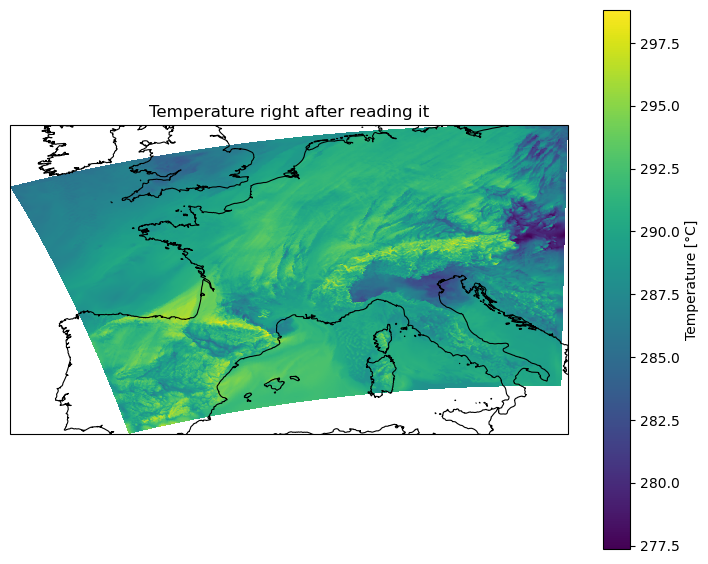

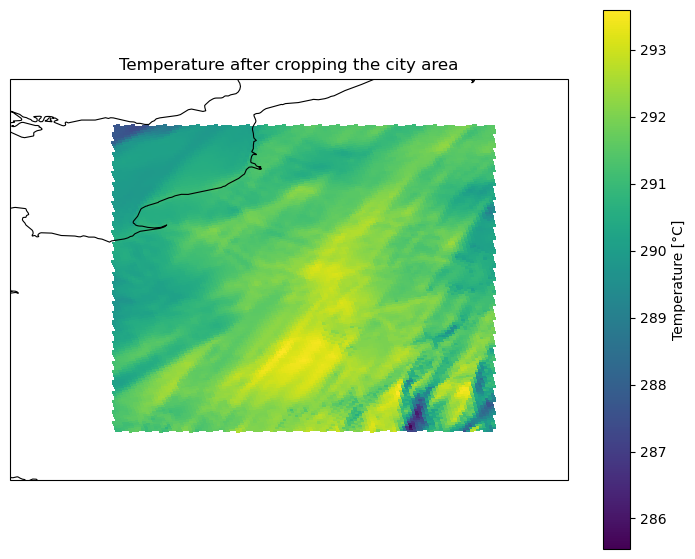

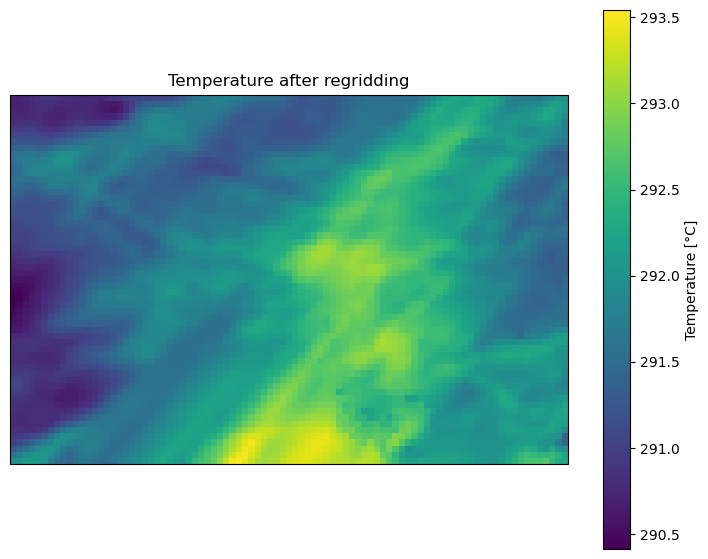

In [1]:
#Import a function from another notebook:
# !pip install import-ipynb
import import_ipynb
from Crop_Interpolate_Grid_Save_In_New_file import newlonlat_city

#Other imports:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt

{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)
Interpolating with method: bilinear
Interpolating with method: nearest_s2d
Interpolating with method: nearest_d2s
Interpolating with method: patch


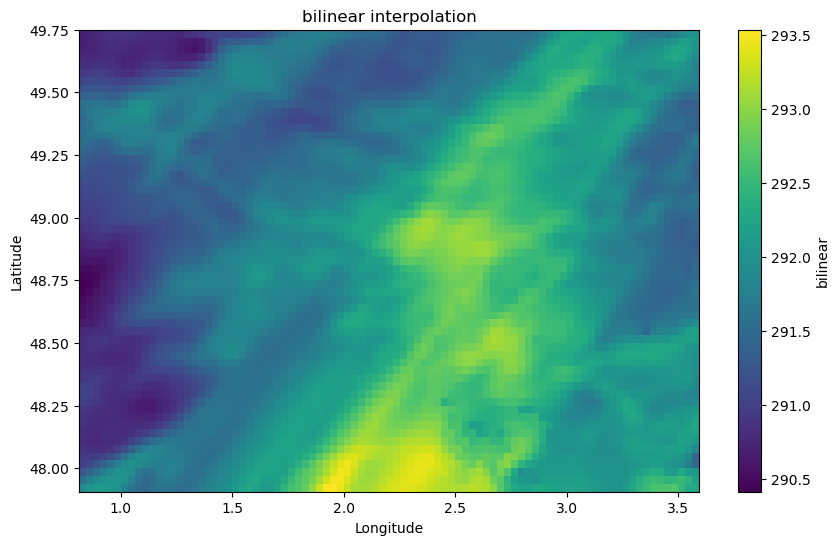

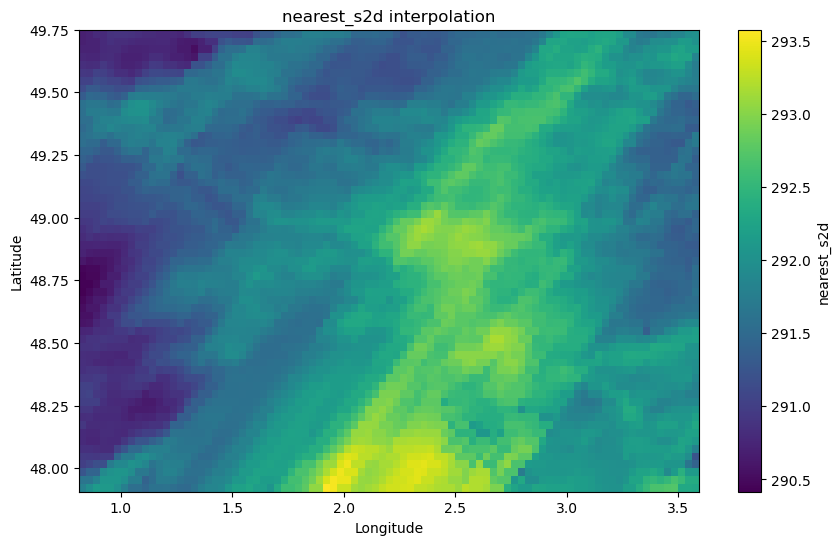

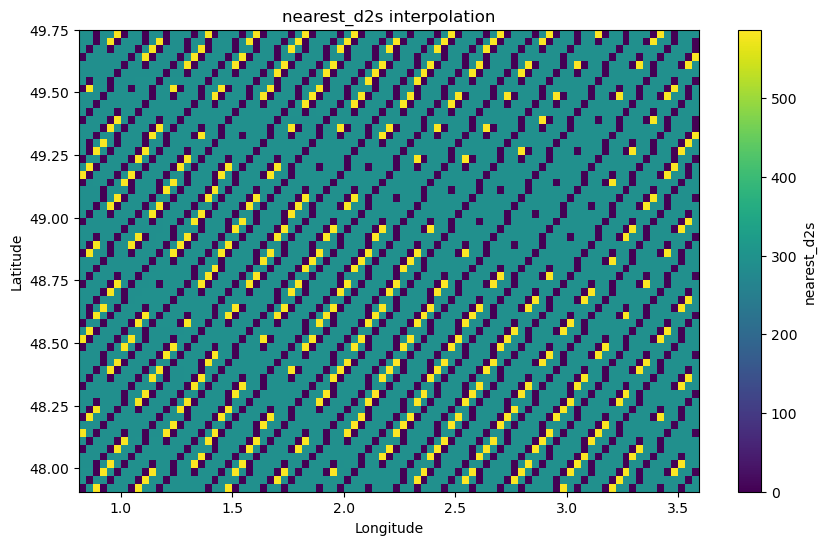

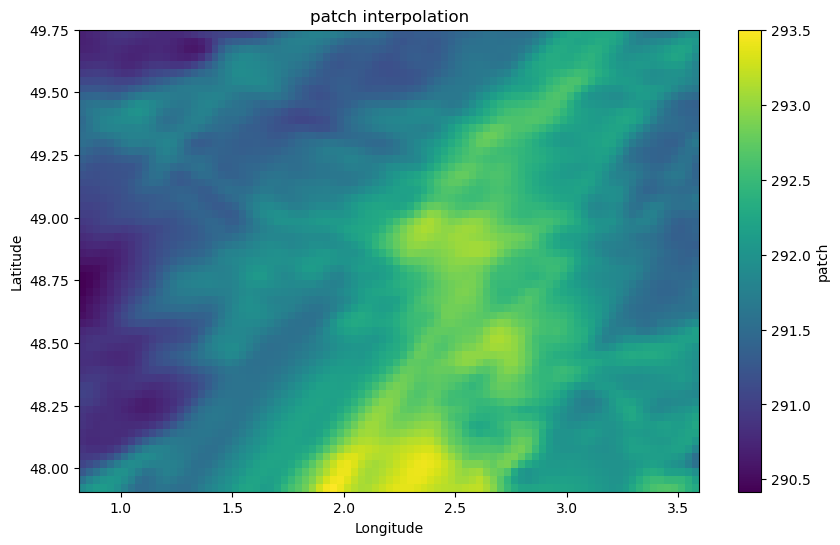

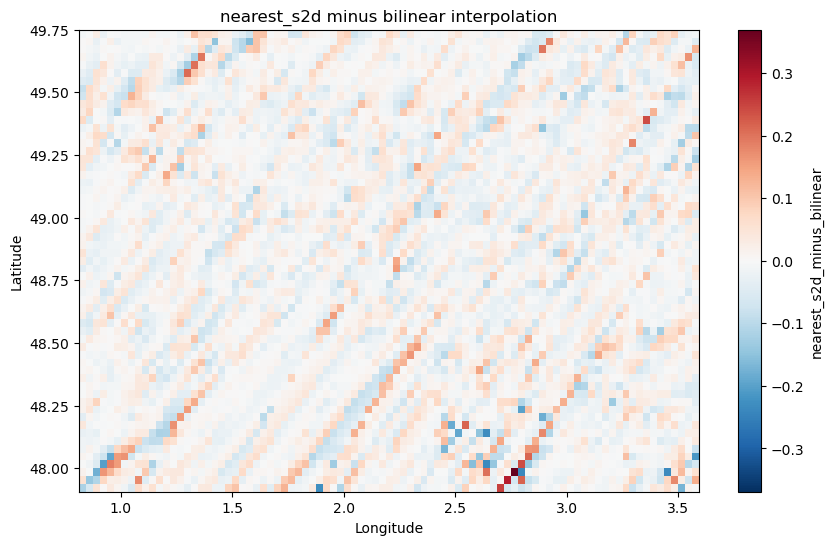

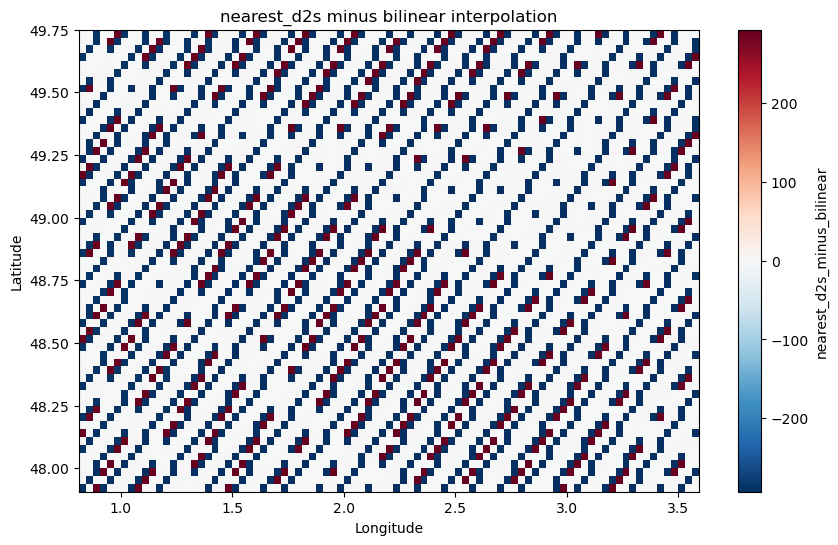

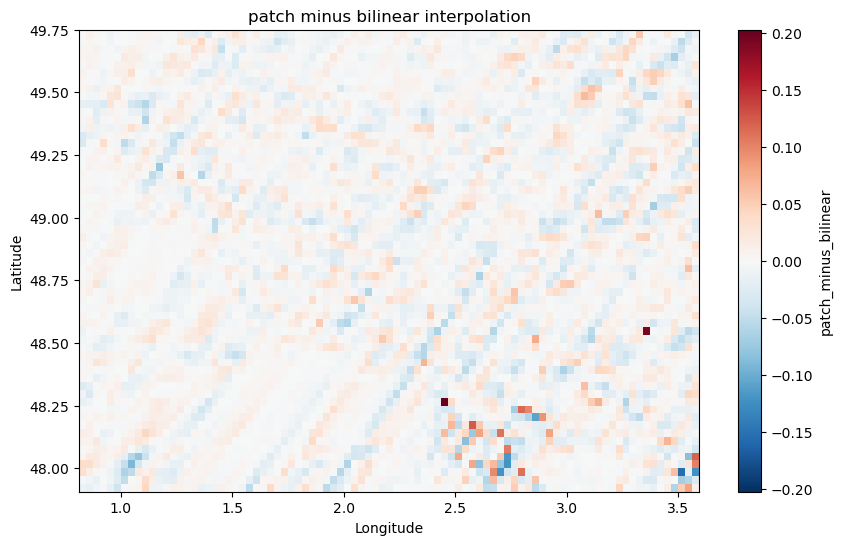

In [34]:
##-----------Variables----------------
#Data path and file name:
path='../utils/'
path_save='../utils/'
file= 'ta1000_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_202301010000-202312311800.nc'
variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period = file.split("_")
# print(variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period)

#City name
city_name='Paris'

# List of interpolation methods to compare
method_list = [
    "bilinear",
    "nearest_s2d",
    "nearest_d2s",
    "patch",
]


# ----Get the target grid coordinates and grid parameters---------
lon_target, lat_target, x_first, xend, x_size, y_size, xinc, yinc, y_first, yend = newlonlat_city(city_name)
#lon_target, lat_target have an extra 1° on each side to avoid losing data at the boundaries during interpolation.
#x_size, y_size are also modified to include the extra degree

# Create 2D longitude and latitude arrays from the 1D coordinates
lon2d_target, lat2d_target = np.meshgrid(lon_target, lat_target)

# Define the target grid as a dataset: Necessary for xESMF regridding
ds_out = xr.Dataset(
    {
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    },
    coords={
        "x": lon_target,
        "y": lat_target,
    }
)

## ---------------Source grid:--------------------
# Read the input dataset
ds = xr.open_dataset(path + file)

# Crop the dataset to the city domain (with the extra degree)
city = ds.where(
    (ds.lon >= x_first-1) & (ds.lon <= xend+1) &
    (ds.lat >= y_first-1) & (ds.lat <= yend+1),
    drop=True
)

# Create the source grid dataset using the original coordinates
ds_in = xr.Dataset(
    {
        "lon": city["lon"],
        "lat": city["lat"],
    })

# Create an empty dataset to store the interpolated fields------------
ds_city_interp = xr.Dataset(
    coords={
        "x": lon_target,
        "y": lat_target,
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    }
)

# -------------Interpolate the variable using each method------------
for method in method_list:
    print(f"Interpolating with method: {method}")
    #Define the regridder
    regridder = xe.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=False,
        ignore_degenerate=True
    )
    #Aply the regridder
    ds_city_interp[method] = regridder(city[variable])
    #ds_city_interp is a dataset with x, y, lon, lat as coordinates and the interpolated variable for each method as variables.

# Compute the difference between each method and bilinear interpolation----
for method in method_list:
    if method != "bilinear":
        ds_city_interp[f"{method}_minus_bilinear"] = (
            ds_city_interp[method] - ds_city_interp["bilinear"]
        )
#Crop the dataset to the city domain without the extra degree-----

#-----------Crop the extra degree:---------------------
# Crop the extra degree from the whole interpolated dataset
ds_city_interp_cropped = ds_city_interp.where(
    (ds_city_interp.lon >= x_first) & (ds_city_interp.lon <= xend) &
    (ds_city_interp.lat >= y_first) & (ds_city_interp.lat <= yend),
    drop=True
)#It recovers the grid size indicagted in the GitHub repository

##--------------------Plotting the results----------------------
#plots of the interpolated fields
for method in method_list:
    plt.figure(figsize=(10, 6))
    ds_city_interp_cropped[method].isel(time=0).plot()
    plt.title(f"{method} interpolation")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

#plots of the differences with bilinear interpolation
for method in method_list:
    if method != "bilinear":
        plt.figure(figsize=(10, 6))
        ds_city_interp_cropped[f"{method}_minus_bilinear"].isel(time=0).plot()
        plt.title(f"{method} minus bilinear interpolation")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()


In [16]:
# ds_out # Dataset with x, y coordenates and lon, lat as variables
# ds = xr.open_dataset(path + file)
# ds_city_interp
# regridder
# ds_city_interp_cropped

For bilinear, nearest_s2d, nearest_d2s, and patch interpolation, the values at the grid-cell centers (the data points) are sufficient. However, for conservative methods, the values at the cell boundaries are also required. In our case, these correspond to intermediate points. For 1D grids, the regridder can calculate them automatically, but for 2D grids, they have to be computed beforehand.


In [ ]:
# ds_city_interp2

<xarray.Dataset> Size: 433MB
Dimensions:                             (x: 152, y: 122, time: 1460)
Coordinates:
  * x                                   (x) float64 1kB -0.1719 ... 4.547
    lon                                 (y, x) float64 148kB -0.1719 ... 4.547
    lat                                 (y, x) float64 148kB 46.92 ... 50.7
  * y                                   (y) float64 976B 46.92 46.95 ... 50.7
  * time                                (time) datetime64[ns] 12kB 2023-01-01...
Data variables:
    conservative                        (time, y, x) float32 108MB nan ... 185.4
    conservative_normed                 (time, y, x) float32 108MB nan ... 281.6
    conservative_minus_bilinear         (time, y, x) float32 108MB nan ... -9...
    conservative_normed_minus_bilinear  (time, y, x) float32 108MB nan ... -0...

Interpolating with method: conservative
Interpolating with method: conservative_normed


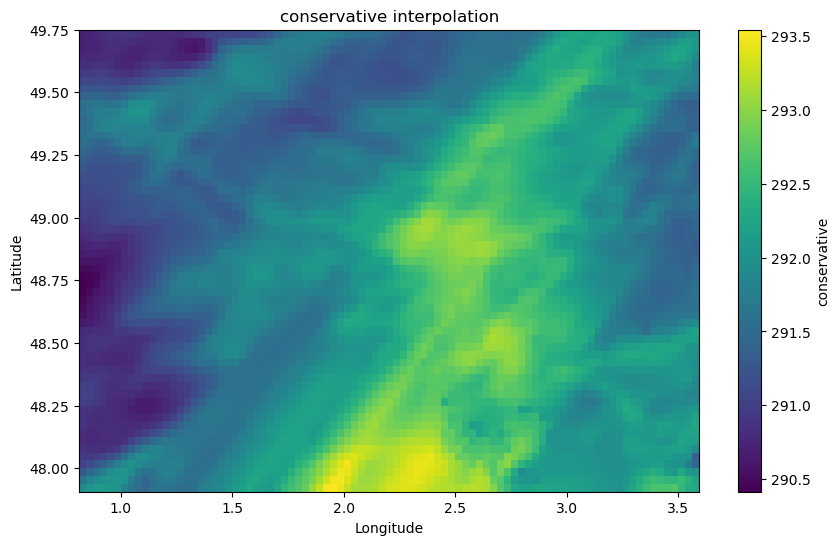

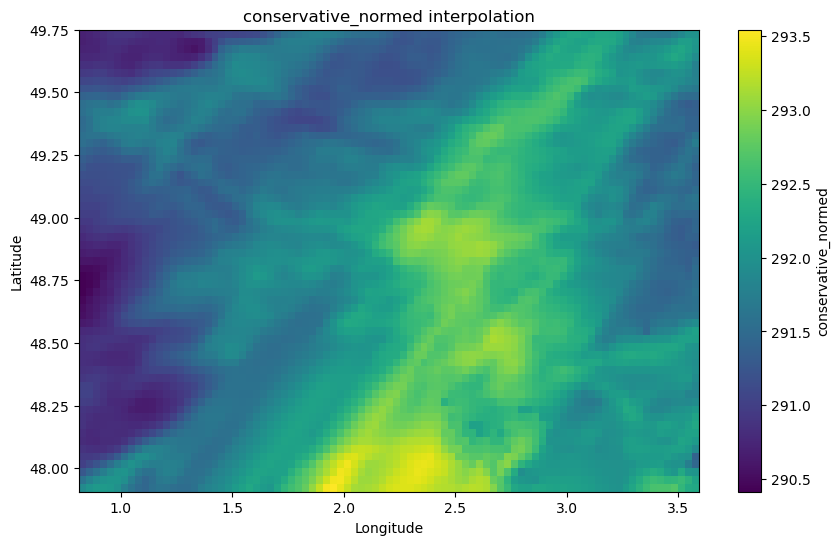

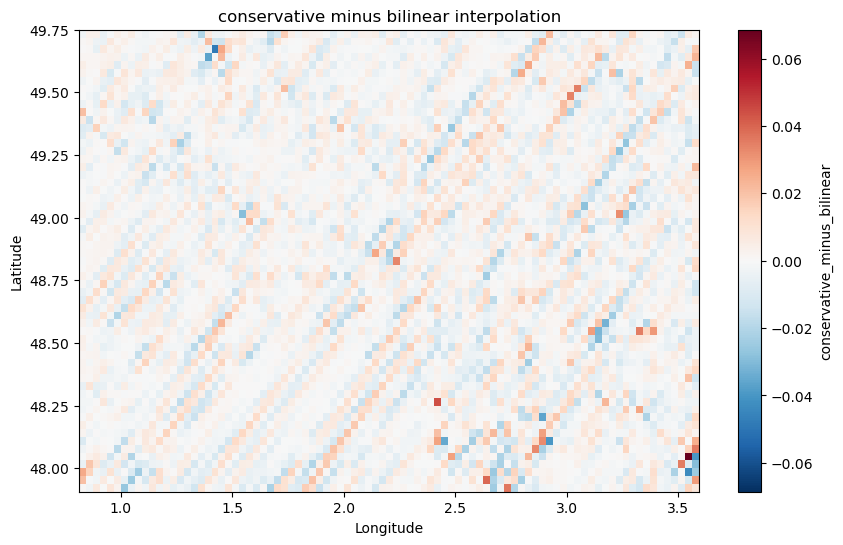

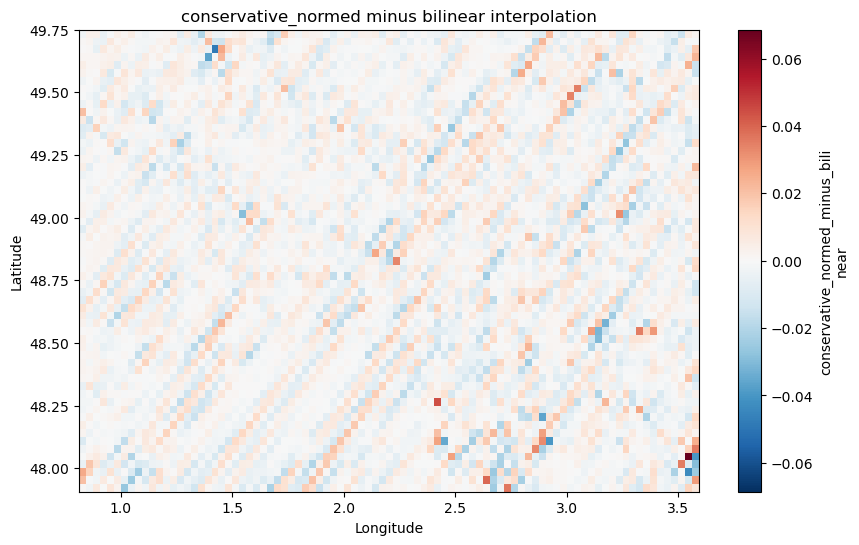

In [39]:

# List of conservative interpolation methods
conservative_method_list = [
    "conservative",
    # "conservative_2nd",#my version of xesmf does'nt incluede this method although it is in the xESMF documentation
    "conservative_normed"]

#Define a function to create 1D cell bounds
def centers_to_bounds_1d(coord):
    """
    Create 1D cell bounds from 1D cell centers.

    Parameters:
    1) coord: 1D array(or similar) of cell centers.

    Returns:
    1) bounds: 1D array of cell bounds.
    """
    coord = np.asarray(coord)#To ensure coord is a numpy array

    # Calculate the midpoints between adjacent cell centers
    mid = 0.5 * (coord[1:] + coord[:-1])

    # Asignation of the first and last bounds as the first and last cell centers
    first = coord[0]
    last = coord[-1]

    bounds = np.concatenate([[first], mid, [last]])

    return bounds


def centers_to_bounds_2d(lon, lat):
    """
    Create 2D cell bounds from 2D cell centers.

    Parameters:
    1) lon: 2D array of longitudinal cell centers.
    2) lat: 2D array of latitudinal cell centers.

    Returns:
    1) lon_b: 2D array of longitudinal cell bounds.
    2) lat_b: 2D array of latitudinal cell bounds.
    """
    lon = np.asarray(lon)#To ensure lon and lat are numpy arrays
    lat = np.asarray(lat)

    ny, nx = lon.shape# lon and lat have the same shape

    lon_b = np.empty((ny + 1, nx + 1))#The bounds grid has one more row and column than the centers grid
    lat_b = np.empty((ny + 1, nx + 1))

    #Calculation of the interior bounds as the average of the four surrounding cell centers
    lon_b[1:-1, 1:-1] = 0.25 * (    # [1:-1, 1:-1] to not include the boundariesof the domain
        lon[:-1, :-1] + lon[1:, :-1] + lon[:-1, 1:] + lon[1:, 1:])#sum uo of the four surrounding points
    lat_b[1:-1, 1:-1] = 0.25 * (
        lat[:-1, :-1] + lat[1:, :-1] + lat[:-1, 1:] + lat[1:, 1:])

    # Complete the boundaries
    lon_b[0, 1:-1] = lon_b[1, 1:-1]#top row, excluding the corners
    lon_b[-1, 1:-1] = lon_b[-2, 1:-1]#bottom row, excluding the corners
    lon_b[1:-1, 0] = lon_b[1:-1, 1]#left column, excluding the corners
    lon_b[1:-1, -1] = lon_b[1:-1, -2]#right column, excluding the corners

    #The same for lat_b
    lat_b[0, 1:-1] = lat_b[1, 1:-1]#top row, excluding the corners
    lat_b[-1, 1:-1] = lat_b[-2, 1:-1]#bottom row, excluding the corners
    lat_b[1:-1, 0] = lat_b[1:-1, 1]#left column, excluding the corners
    lat_b[1:-1, -1] = lat_b[1:-1, -2]#right column, excluding the corners

    #Complete the corners using the values of the adjacent bounds
    lon_b[0, 0] = lon_b[0, 1] + lon_b[1, 0] - lon_b[1, 1]
    lon_b[0, -1] = lon_b[0, -2] + lon_b[1, -1] - lon_b[1, -2]
    lon_b[-1, 0] = lon_b[-2, 0] + lon_b[-1, 1] - lon_b[-2, 1]
    lon_b[-1, -1] = lon_b[-2, -1] + lon_b[-1, -2] - lon_b[-2, -2]
    
    # The same for lat_b
    lat_b[0, 0] = lat_b[0, 1] + lat_b[1, 0] - lat_b[1, 1]
    lat_b[0, -1] = lat_b[0, -2] + lat_b[1, -1] - lat_b[1, -2]
    lat_b[-1, 0] = lat_b[-2, 0] + lat_b[-1, 1] - lat_b[-2, 1]
    lat_b[-1, -1] = lat_b[-2, -1] + lat_b[-1, -2] - lat_b[-2, -2]

    return lon_b, lat_b


# lon_target, lat_target, x_first, xend, x_size, y_size, xinc, yinc, y_first, yend = newlonlat_city(city_name)

# lon2d_target, lat2d_target = np.meshgrid(lon_target, lat_target)

#-----------Targed grid------------------
#Obtention of the target bound grid (data points position not included):
lon_b_target_1d = centers_to_bounds_1d(lon_target)
lat_b_target_1d = centers_to_bounds_1d(lat_target)
lon2d_b_target, lat2d_b_target = np.meshgrid(lon_b_target_1d, lat_b_target_1d)

#Target grid dataset including the positions of the data points and boundaries
ds_out = xr.Dataset(
    {
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
        "lon_b": (("y_b", "x_b"), lon2d_b_target),
        "lat_b": (("y_b", "x_b"), lat2d_b_target),
    },
    coords={
        "x": lon_target,
        "y": lat_target,
        "x_b": lon_b_target_1d,
        "y_b": lat_b_target_1d,
    }
)



#--------------Initial grid---------------------- 
# ds = xr.open_dataset(path + file)

# city = ds.where(
#     (ds.lon >= x_first) & (ds.lon <= xend) &
#     (ds.lat >= y_first) & (ds.lat <= yend),
#     drop=True
# )

#Obtention of the target bound grid (data points position not included):
lon_b_source, lat_b_source = centers_to_bounds_2d(
    city["lon"].values,
    city["lat"].values
)

#Initial grid dataset including the positions of the data points and boundaries
ds_in = xr.Dataset(
    {
        "lon": city["lon"],
        "lat": city["lat"],
        "lon_b": (("y_b", "x_b"), lon_b_source),
        "lat_b": (("y_b", "x_b"), lat_b_source),
    }
)

# ----------------empty dataset to store the interpolated fields------------
ds_city_interp2 = xr.Dataset(
    coords={
        "x": lon_target,
        "y": lat_target,
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    }
)

# successful_methods = []??

# -------------Interpolate the variable using each method------------
for method in conservative_method_list:
    print(f"Interpolating with method: {method}")
    regridder = xe.Regridder(
            ds_in,
            ds_out,
            method=method,
            periodic=False,
            ignore_degenerate=True,
            unmapped_to_nan=True
    )

    ds_city_interp2[method] = regridder(city[variable])

# Compute the difference between each method and bilinear interpolation----
for method in conservative_method_list:
        ds_city_interp2[f"{method}_minus_bilinear"] = (
            ds_city_interp2[method] - ds_city_interp["bilinear"]
        )


# Crop the extra degree from the whole interpolated dataset
ds_city_interp_cropped2 = ds_city_interp2.where(
    (ds_city_interp2.lon >= x_first) & (ds_city_interp2.lon <= xend) &
    (ds_city_interp2.lat >= y_first) & (ds_city_interp2.lat <= yend),
    drop=True
)#It recovers the grid size indicagted in the GitHub repository


##--------------------Plotting the results----------------------
#plots of the interpolated fields
for method in conservative_method_list:
    plt.figure(figsize=(10, 6))
    ds_city_interp_cropped2[method].isel(time=0).plot()
    plt.title(f"{method} interpolation")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

#plots of the differences with bilinear interpolation
for method in conservative_method_list:
    plt.figure(figsize=(10, 6))
    ds_city_interp_cropped2[f"{method}_minus_bilinear"].isel(time=0).plot()
    plt.title(f"{method} minus bilinear interpolation")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

Results:

The spatial interpolation pattern is very similar for the bilinear, nearest_s2d, patch, conservative, and conservative_normed methods. The most similar methods are bilinear and the conservative methods, with differences ranging from -0.06 to 0.06. The differences between bilinear and nearest_s2d range from -0.35 to 0.35, while the differences between bilinear and patch range from -0.2 to 0.2.

The nearest_d2s method shows very marked diagonal patterns and only produces three distinct values, with no spatial continuity. Much of the spatial information is lost, making this method unsuitable for this case.
